# Actividad 8 — Crear los Esquemas en PostgreSQL

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Conectar a PostgreSQL, crear la base de datos `limon_analytics_db` y ejecutar el DDL generado en la Actividad 7 para crear todas las tablas del Star Schema.

## Prerequisito
> PostgreSQL debe estar corriendo localmente en el puerto 5432.  
> Credenciales: `user=postgres`, `password=postgres`  
> Si PostgreSQL no esta disponible, el notebook mostrara el DDL para ejecucion manual.

## Regla de esta actividad
> Solo se crea el esquema. Los datos NO se cargan aqui (eso es Actividad 9).


## Configuracion inicial


In [1]:
import os, sys, json, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
OUTPUT = CONFIG['output']

# Credenciales PostgreSQL
PG_USER = 'postgres'
PG_PASS = 'postgres'
PG_HOST = 'localhost'
PG_PORT = '5432'
PG_DB   = 'limon_analytics_db'
PG_URI  = f'postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}'
PG_URI_DEFAULT = f'postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/postgres'

print('Config cargado OK | Raiz:', os.getcwd())
print(f'PostgreSQL target: {PG_HOST}:{PG_PORT}/{PG_DB}')
print(f'Usuario: {PG_USER}')


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
PostgreSQL target: localhost:5432/limon_analytics_db
Usuario: postgres


---
# 1. Verificacion de Conexion a PostgreSQL


In [2]:
import psycopg2
from psycopg2 import OperationalError

PG_DISPONIBLE = False

try:
    conn_test = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database='postgres',
        connect_timeout=5
    )
    cursor = conn_test.cursor()
    cursor.execute('SELECT version();')
    version = cursor.fetchone()[0]
    cursor.close()
    conn_test.close()
    PG_DISPONIBLE = True
    print('OK: Conexion a PostgreSQL exitosa.')
    print(f'Version: {version[:60]}')
    print(f'Host: {PG_HOST}:{PG_PORT}')
    print(f'Usuario: {PG_USER}')
except OperationalError as e:
    print('ERROR: No se pudo conectar a PostgreSQL.')
    print(f'Detalle: {e}')
    print()
    print('INSTRUCCIONES PARA INSTALAR POSTGRESQL:')
    print('  1. Descargar desde: https://www.postgresql.org/download/windows/')
    print('  2. Instalar con usuario postgres y password postgres')
    print('  3. Verificar que el servicio esta corriendo en el puerto 5432')
    print('  4. Re-ejecutar este notebook')
    print()
    print('ALTERNATIVA: Ejecutar el DDL manualmente en pgAdmin o psql:')
    print(f'  Archivo DDL: {OUTPUT["dwh"]}dwh_star_schema.sql')


OK: Conexion a PostgreSQL exitosa.
Version: PostgreSQL 16.13, compiled by Visual C++ build 1944, 64-bit
Host: localhost:5432
Usuario: postgres


### Interpretacion

**Que muestra:** El resultado de la conexion a PostgreSQL. Si la conexion es exitosa, se muestra la version del servidor. Si falla, se muestran instrucciones de instalacion.

**Implicacion para el pipeline:** Si PostgreSQL no esta disponible, las Actividades 8 y 9 no pueden ejecutarse completamente. Sin embargo, el dataset maestro CSV sigue siendo valido para el modelo LSTM-Attention.

**Nota:** Para la tesis, PostgreSQL es el repositorio oficial del Data Warehouse. El modelo puede entrenarse directamente desde el CSV, pero el DWH permite consultas analiticas mas eficientes y es parte del entregable de ingenieria de datos.


---
# 2. Crear la Base de Datos limon_analytics_db


In [3]:
if PG_DISPONIBLE:
    conn_admin = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database='postgres'
    )
    conn_admin.autocommit = True
    cursor_admin = conn_admin.cursor()

    # Verificar si la base de datos ya existe
    cursor_admin.execute(
        "SELECT 1 FROM pg_database WHERE datname = %s", (PG_DB,)
    )
    existe = cursor_admin.fetchone() is not None

    if existe:
        print(f'La base de datos {PG_DB} ya existe.')
        print('Se usara la base de datos existente.')
        print('Para recrearla desde cero, ejecutar manualmente:')
        print(f'  DROP DATABASE {PG_DB};')
        print(f'  CREATE DATABASE {PG_DB};')
    else:
        cursor_admin.execute(f'CREATE DATABASE {PG_DB}')
        print(f'OK: Base de datos {PG_DB} creada exitosamente.')

    cursor_admin.close()
    conn_admin.close()
else:
    print('PostgreSQL no disponible. Saltando creacion de base de datos.')


La base de datos limon_analytics_db ya existe.
Se usara la base de datos existente.
Para recrearla desde cero, ejecutar manualmente:
  DROP DATABASE limon_analytics_db;
  CREATE DATABASE limon_analytics_db;


---
# 3. Ejecutar el DDL — Crear las Tablas del Star Schema


In [4]:
# Leer el DDL generado en la Actividad 7
ddl_path = OUTPUT['dwh'] + 'dwh_star_schema.sql'
with open(ddl_path, 'r', encoding='utf-8') as f:
    ddl_completo = f.read()

print('DDL a ejecutar:')
print('=' * 60)
print(ddl_completo)
print('=' * 60)


DDL a ejecutar:

-- =================================================================
-- STAR SCHEMA: limon_analytics_db
-- Proyecto: Prediccion de Produccion de Limon — LSTM-Attention
-- Generado por: Pipeline Fase 1 — Actividad 7
-- =================================================================

-- 1. Dimension Tiempo
CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo     SERIAL PRIMARY KEY,
    fecha_evento  VARCHAR(7)  NOT NULL UNIQUE,
    anho          SMALLINT    NOT NULL,
    mes           SMALLINT    NOT NULL,
    trimestre     SMALLINT    GENERATED ALWAYS AS (((mes - 1) / 3) + 1) STORED,
    nombre_mes    VARCHAR(20)
);

-- 2. Dimension Ubicacion
CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion  SERIAL PRIMARY KEY,
    departamento  VARCHAR(60) NOT NULL,
    provincia     VARCHAR(60) NOT NULL,
    region_natural VARCHAR(20),
    UNIQUE (departamento, provincia)
);

-- 3. Dimension Clima (NASA POWER)
CREATE TABLE IF NOT EXISTS dim_clima (
    id_clima          

In [5]:
if PG_DISPONIBLE:
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    conn.autocommit = True
    cursor = conn.cursor()

    # Eliminar tablas existentes en orden correcto (hechos primero)
    tablas_drop = ['fact_produccion_limon','dim_clima','dim_emergencia',
                   'dim_noticias','dim_tiempo','dim_ubicacion']
    print('Eliminando tablas existentes (si las hay)...')
    for tabla in tablas_drop:
        cursor.execute(f'DROP TABLE IF EXISTS {tabla} CASCADE')
        print(f'  DROP {tabla}: OK')

    # Ejecutar el DDL completo
    print()
    print('Creando tablas con el DDL de la Actividad 7...')
    try:
        cursor.execute(ddl_completo)
        print('OK: DDL ejecutado exitosamente.')
        print('Todas las tablas e indices creados.')
        resultados = [('DDL completo', 'OK', '')]
    except Exception as e:
        print(f'ERROR: {e}')
        resultados = [('DDL completo', 'ERROR', str(e))]

    cursor.close()
    conn.close()
else:
    print('PostgreSQL no disponible.')
    print('El DDL esta guardado en:', ddl_path)
    resultados = []


Eliminando tablas existentes (si las hay)...
  DROP fact_produccion_limon: OK
  DROP dim_clima: OK
  DROP dim_emergencia: OK
  DROP dim_noticias: OK
  DROP dim_tiempo: OK
  DROP dim_ubicacion: OK

Creando tablas con el DDL de la Actividad 7...
OK: DDL ejecutado exitosamente.
Todas las tablas e indices creados.


---
# 4. Verificacion del Esquema Creado


In [6]:
if PG_DISPONIBLE:
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    # Listar tablas creadas
    cursor.execute("""
        SELECT table_name, 
               (SELECT COUNT(*) FROM information_schema.columns c
                WHERE c.table_name = t.table_name
                AND c.table_schema = 'public') as n_cols
        FROM information_schema.tables t
        WHERE table_schema = 'public'
        AND table_type = 'BASE TABLE'
        ORDER BY table_name;
    """)
    tablas = cursor.fetchall()

    print('Tablas creadas en limon_analytics_db:')
    print(f'{"Tabla":<35} {"Columnas"}')
    print('-' * 50)
    for tabla, n_cols in tablas:
        print(f'  {tabla:<33} {n_cols}')

    # Listar indices
    cursor.execute("""
        SELECT indexname, tablename
        FROM pg_indexes
        WHERE schemaname = 'public'
        ORDER BY tablename, indexname;
    """)
    indices = cursor.fetchall()
    print()
    print(f'Indices creados: {len(indices)}')
    for idx, tbl in indices:
        print(f'  {idx:<40} -> {tbl}')

    cursor.close()
    conn.close()

    tablas_esperadas = ['dim_tiempo','dim_ubicacion','dim_clima',
                        'dim_emergencia','dim_noticias','fact_produccion_limon']
    tablas_creadas = [t[0] for t in tablas]
    faltantes = [t for t in tablas_esperadas if t not in tablas_creadas]
    print()
    if not faltantes:
        print('OK: Todas las tablas del Star Schema fueron creadas correctamente.')
    else:
        print(f'FALTANTES: {faltantes}')
else:
    print('PostgreSQL no disponible. Verificacion omitida.')
    tablas = []
    indices = []


Tablas creadas en limon_analytics_db:
Tabla                               Columnas
--------------------------------------------------
  dim_clima                         9
  dim_emergencia                    4
  dim_noticias                      3
  dim_tiempo                        6
  dim_ubicacion                     4
  fact_produccion_limon             9



Indices creados: 16
  dim_clima_pkey                           -> dim_clima
  dim_emergencia_pkey                      -> dim_emergencia
  dim_noticias_pkey                        -> dim_noticias
  dim_tiempo_fecha_evento_key              -> dim_tiempo
  dim_tiempo_pkey                          -> dim_tiempo
  idx_tiempo_fecha                         -> dim_tiempo
  dim_ubicacion_departamento_provincia_key -> dim_ubicacion
  dim_ubicacion_pkey                       -> dim_ubicacion
  idx_ubic_dpto_prov                       -> dim_ubicacion
  fact_produccion_limon_id_tiempo_id_ubicacion_key -> fact_produccion_limon
  fact_produccion_limon_pkey               -> fact_produccion_limon
  idx_fact_clima                           -> fact_produccion_limon
  idx_fact_emergencia                      -> fact_produccion_limon
  idx_fact_noticias                        -> fact_produccion_limon
  idx_fact_tiempo                          -> fact_produccion_limon
  idx_fact_ubicacion                

## Previsualizacion detallada del esquema creado

Estructura completa de cada tabla: columnas, tipos de datos, constraints y relaciones.


In [7]:
if PG_DISPONIBLE:
    import psycopg2
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    # Obtener estructura completa de cada tabla
    tablas_orden = ['dim_tiempo','dim_ubicacion','dim_clima',
                    'dim_emergencia','dim_noticias','fact_produccion_limon']
    colores_tablas = {
        'dim_tiempo':            '#2980b9',
        'dim_ubicacion':         '#27ae60',
        'dim_clima':             '#8e44ad',
        'dim_emergencia':        '#e67e22',
        'dim_noticias':          '#16a085',
        'fact_produccion_limon': '#c0392b',
    }

    # Obtener columnas de cada tabla
    estructura = {}
    for tabla in tablas_orden:
        cursor.execute("""
            SELECT
                c.column_name,
                c.data_type,
                c.is_nullable,
                c.column_default,
                CASE WHEN tc.constraint_type = 'PRIMARY KEY' THEN 'PK'
                     WHEN tc.constraint_type = 'FOREIGN KEY' THEN 'FK'
                     WHEN tc.constraint_type = 'UNIQUE' THEN 'UQ'
                     ELSE '' END as constraint_type
            FROM information_schema.columns c
            LEFT JOIN information_schema.key_column_usage kcu
                ON c.table_name = kcu.table_name
                AND c.column_name = kcu.column_name
                AND c.table_schema = kcu.table_schema
            LEFT JOIN information_schema.table_constraints tc
                ON kcu.constraint_name = tc.constraint_name
                AND kcu.table_schema = tc.table_schema
            WHERE c.table_name = %s AND c.table_schema = 'public'
            ORDER BY c.ordinal_position;
        """, (tabla,))
        estructura[tabla] = cursor.fetchall()

    # Imprimir estructura detallada
    print('=' * 70)
    print('  ESTRUCTURA DEL STAR SCHEMA — limon_analytics_db')
    print('=' * 70)
    print()

    for tabla in tablas_orden:
        cols = estructura[tabla]
        tipo_tabla = 'TABLA DE HECHOS' if tabla == 'fact_produccion_limon' else 'DIMENSION'
        print(f'  [{tipo_tabla}] {tabla.upper()}')
        print(f'  {"─" * 60}')
        print(f'  {"Columna":<30} {"Tipo":<20} {"Nulo":<6} {"Key"}')
        print(f'  {"─" * 60}')
        seen = set()
        for col_name, data_type, nullable, default, constraint in cols:
            if col_name in seen:
                continue
            seen.add(col_name)
            key_icon = '🔑 PK' if constraint == 'PK' else '🔗 FK' if constraint == 'FK' else ''
            null_str = 'SI' if nullable == 'YES' else 'NO'
            tipo_short = data_type.replace('character varying','VARCHAR').replace('integer','INT').replace('double precision','FLOAT')
            print(f'  {col_name:<30} {tipo_short:<20} {null_str:<6} {key_icon}')
        print(f'  Total columnas: {len(set(c[0] for c in cols))}')
        print()

    # Obtener FK relationships
    cursor.execute("""
        SELECT
            tc.table_name as tabla_origen,
            kcu.column_name as columna_fk,
            ccu.table_name as tabla_destino,
            ccu.column_name as columna_pk
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
            ON tc.constraint_name = kcu.constraint_name
        JOIN information_schema.constraint_column_usage ccu
            ON ccu.constraint_name = tc.constraint_name
        WHERE tc.constraint_type = 'FOREIGN KEY'
        AND tc.table_schema = 'public'
        ORDER BY tc.table_name;
    """)
    fks = cursor.fetchall()

    print('  RELACIONES (FOREIGN KEYS)')
    print(f'  {"─" * 60}')
    for origen, col_fk, destino, col_pk in fks:
        print(f'  {origen}.{col_fk} → {destino}.{col_pk}')

    cursor.close()
    conn.close()
else:
    print('PostgreSQL no disponible.')


  ESTRUCTURA DEL STAR SCHEMA — limon_analytics_db

  [DIMENSION] DIM_TIEMPO
  ────────────────────────────────────────────────────────────
  Columna                        Tipo                 Nulo   Key
  ────────────────────────────────────────────────────────────
  id_tiempo                      INT                  NO     🔑 PK
  fecha_evento                   VARCHAR              NO     
  anho                           smallint             NO     
  mes                            smallint             NO     
  trimestre                      smallint             SI     
  nombre_mes                     VARCHAR              SI     
  Total columnas: 6

  [DIMENSION] DIM_UBICACION
  ────────────────────────────────────────────────────────────
  Columna                        Tipo                 Nulo   Key
  ────────────────────────────────────────────────────────────
  id_ubicacion                   INT                  NO     🔑 PK
  departamento                   VARCHAR           

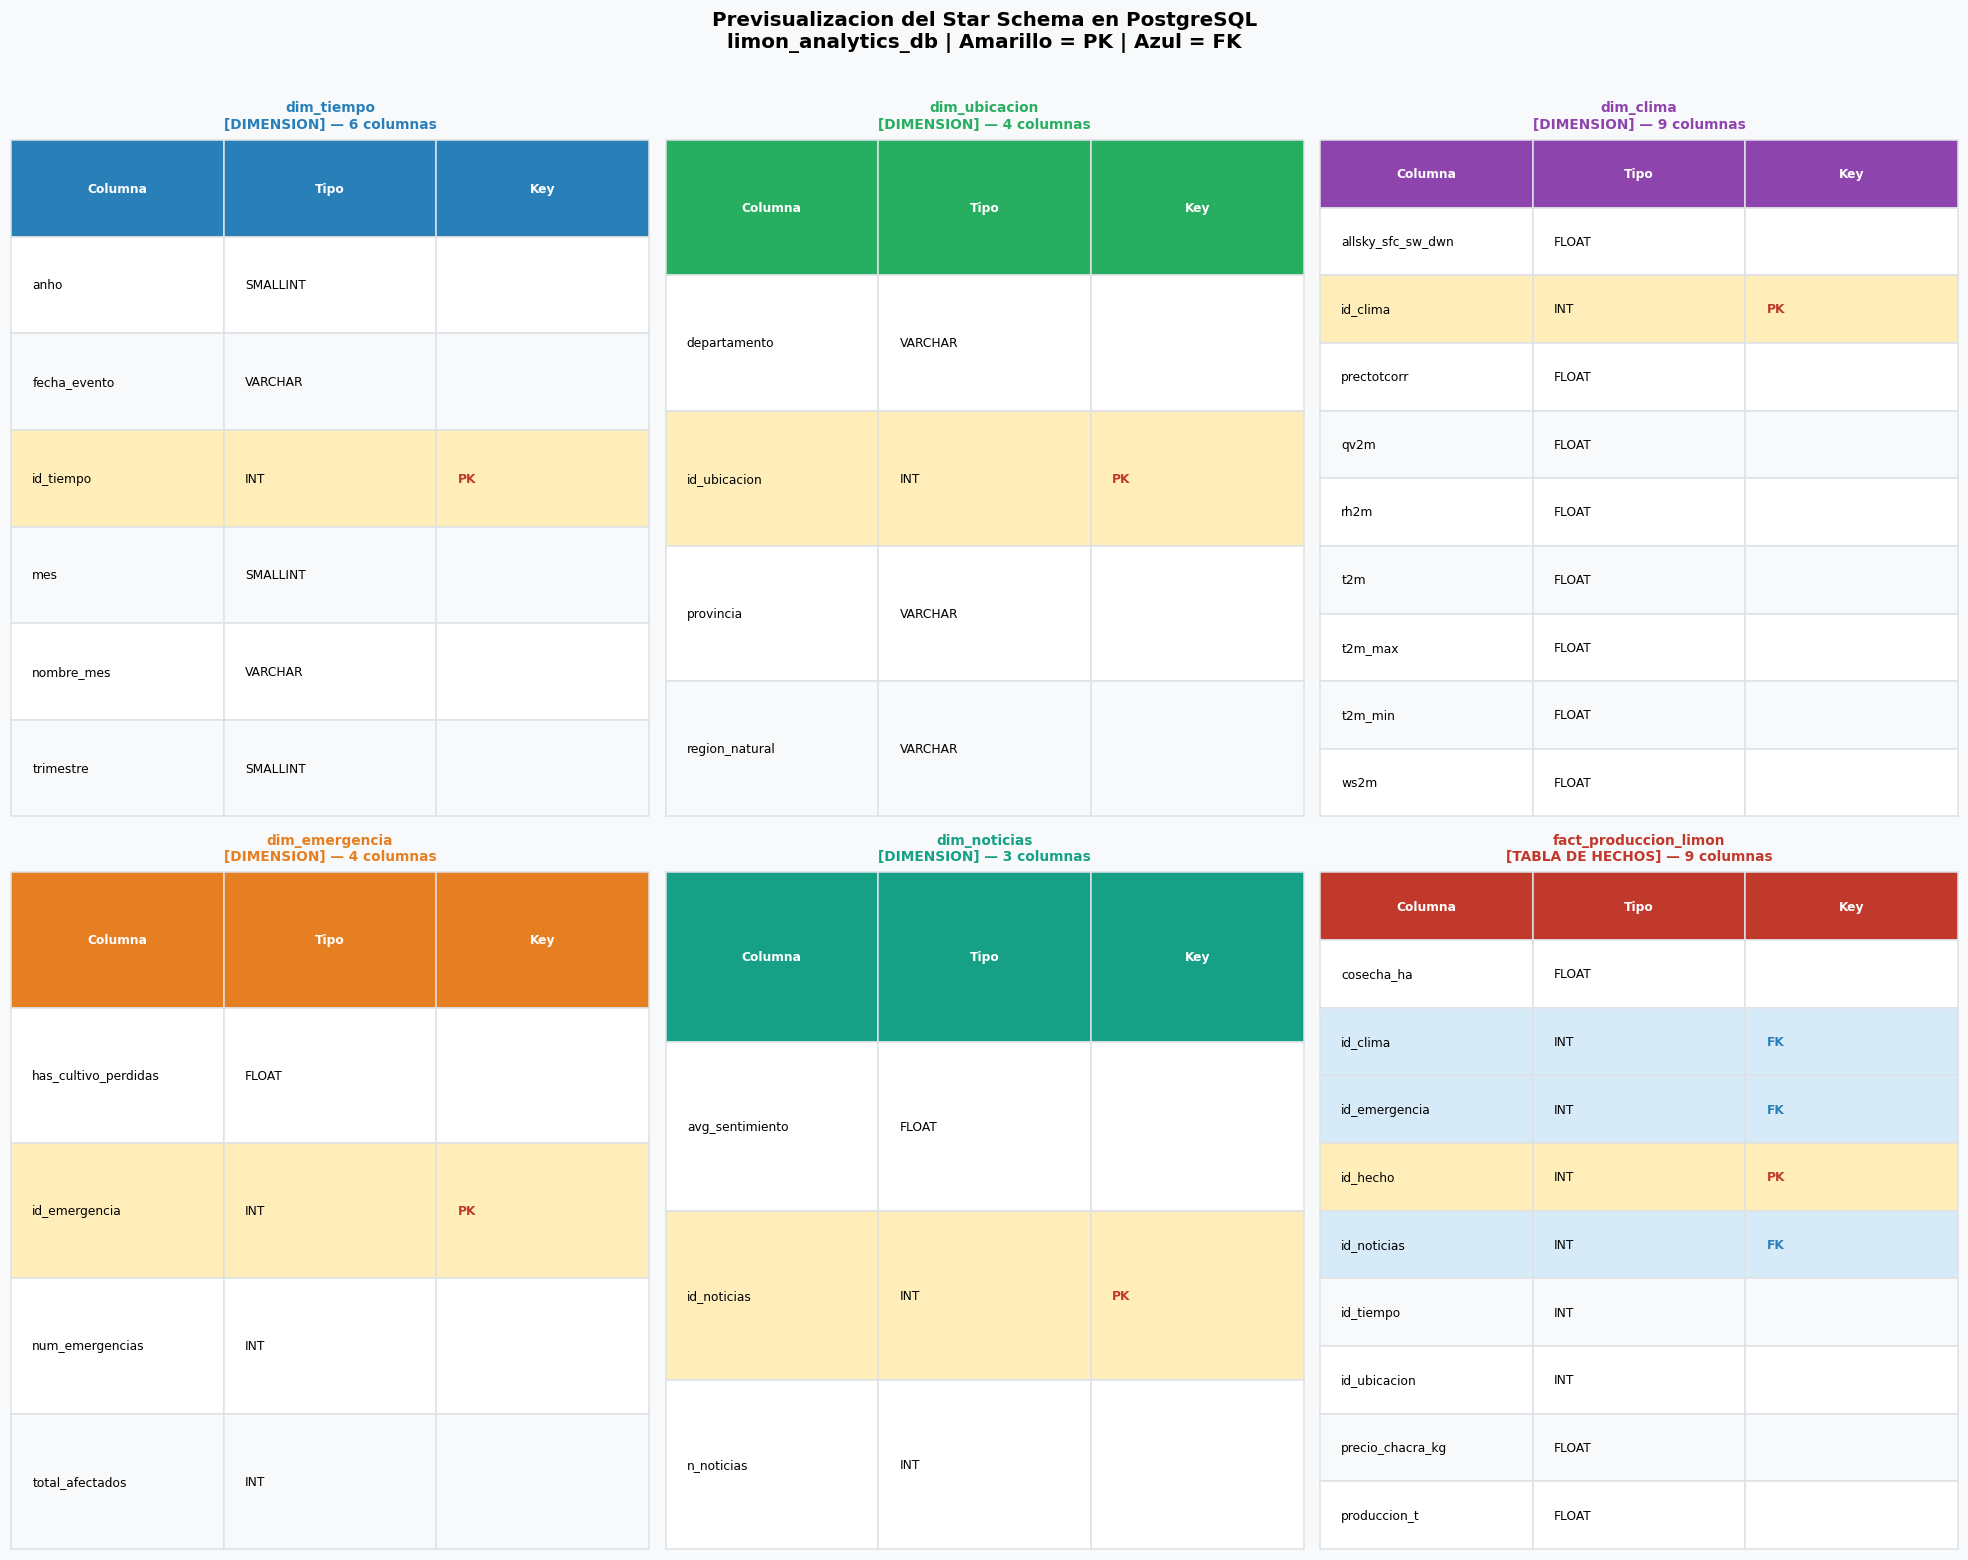

Guardado: pipeline/output/07_dwh/previsualizacion_schema.png


In [8]:
if PG_DISPONIBLE:
    import psycopg2
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    tablas_orden = ['dim_tiempo','dim_ubicacion','dim_clima',
                    'dim_emergencia','dim_noticias','fact_produccion_limon']
    colores_tablas = {
        'dim_tiempo':            '#2980b9',
        'dim_ubicacion':         '#27ae60',
        'dim_clima':             '#8e44ad',
        'dim_emergencia':        '#e67e22',
        'dim_noticias':          '#16a085',
        'fact_produccion_limon': '#c0392b',
    }

    # Obtener columnas de cada tabla
    estructura = {}
    for tabla in tablas_orden:
        cursor.execute("""
            SELECT DISTINCT c.column_name, c.data_type,
                CASE WHEN tc.constraint_type = 'PRIMARY KEY' THEN 'PK'
                     WHEN tc.constraint_type = 'FOREIGN KEY' THEN 'FK'
                     ELSE '' END as key_type
            FROM information_schema.columns c
            LEFT JOIN information_schema.key_column_usage kcu
                ON c.table_name = kcu.table_name AND c.column_name = kcu.column_name
                AND c.table_schema = kcu.table_schema
            LEFT JOIN information_schema.table_constraints tc
                ON kcu.constraint_name = tc.constraint_name
                AND kcu.table_schema = tc.table_schema
            WHERE c.table_name = %s AND c.table_schema = 'public'
            ORDER BY c.column_name;
        """, (tabla,))
        estructura[tabla] = cursor.fetchall()

    cursor.close()
    conn.close()

    # Crear figura con una tabla por panel
    fig, axes = plt.subplots(2, 3, figsize=(18, 14))
    axes = axes.flatten()
    fig.patch.set_facecolor('#f8f9fa')

    for ax, tabla in zip(axes, tablas_orden):
        ax.axis('off')
        ax.set_facecolor('#f8f9fa')
        color = colores_tablas.get(tabla, '#2c3e50')

        cols = estructura[tabla]
        # Deduplicar
        seen = set()
        cols_uniq = []
        for c in cols:
            if c[0] not in seen:
                seen.add(c[0])
                cols_uniq.append(c)

        # Datos para la tabla visual
        data = []
        for col_name, data_type, key_type in cols_uniq:
            tipo_short = (data_type
                .replace('character varying','VARCHAR')
                .replace('integer','INT')
                .replace('double precision','FLOAT')
                .replace('smallint','SMALLINT')
                .replace('real','FLOAT'))
            key_str = key_type if key_type else ''
            data.append([col_name, tipo_short, key_str])

        if not data:
            ax.text(0.5, 0.5, f'{tabla}\n(sin columnas)', ha='center', va='center',
                    fontsize=10, color='gray')
            continue

        tabla_vis = ax.table(
            cellText=data,
            colLabels=['Columna', 'Tipo', 'Key'],
            cellLoc='left', loc='center',
            bbox=[0, 0, 1, 1]
        )
        tabla_vis.auto_set_font_size(False)
        tabla_vis.set_fontsize(8)

        for (row, col), cell in tabla_vis.get_celld().items():
            if row == 0:
                cell.set_facecolor(color)
                cell.set_text_props(color='white', fontweight='bold')
            else:
                key_val = data[row-1][2] if row <= len(data) else ''
                if key_val == 'PK':
                    cell.set_facecolor('#ffeeba')
                    if col == 2: cell.set_text_props(color='#c0392b', fontweight='bold')
                elif key_val == 'FK':
                    cell.set_facecolor('#d6eaf8')
                    if col == 2: cell.set_text_props(color='#2980b9', fontweight='bold')
                else:
                    cell.set_facecolor('#f8f9fa' if row % 2 == 0 else 'white')
            cell.set_edgecolor('#dee2e6')

        tipo_label = 'TABLA DE HECHOS' if tabla == 'fact_produccion_limon' else 'DIMENSION'
        ax.set_title(f'{tabla}\n[{tipo_label}] — {len(cols_uniq)} columnas',
                     fontsize=9, fontweight='bold', color=color, pad=8)

    plt.suptitle('Previsualizacion del Star Schema en PostgreSQL\n'
                 'limon_analytics_db | Amarillo = PK | Azul = FK',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    g_prev = OUTPUT['dwh'] + 'previsualizacion_schema.png'
    plt.savefig(g_prev, dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()
    print('Guardado:', g_prev)
else:
    print('PostgreSQL no disponible.')


## Diagrama UML Estrella — Tablas creadas en PostgreSQL

Diagrama generado dinamicamente desde la estructura real de `limon_analytics_db`.


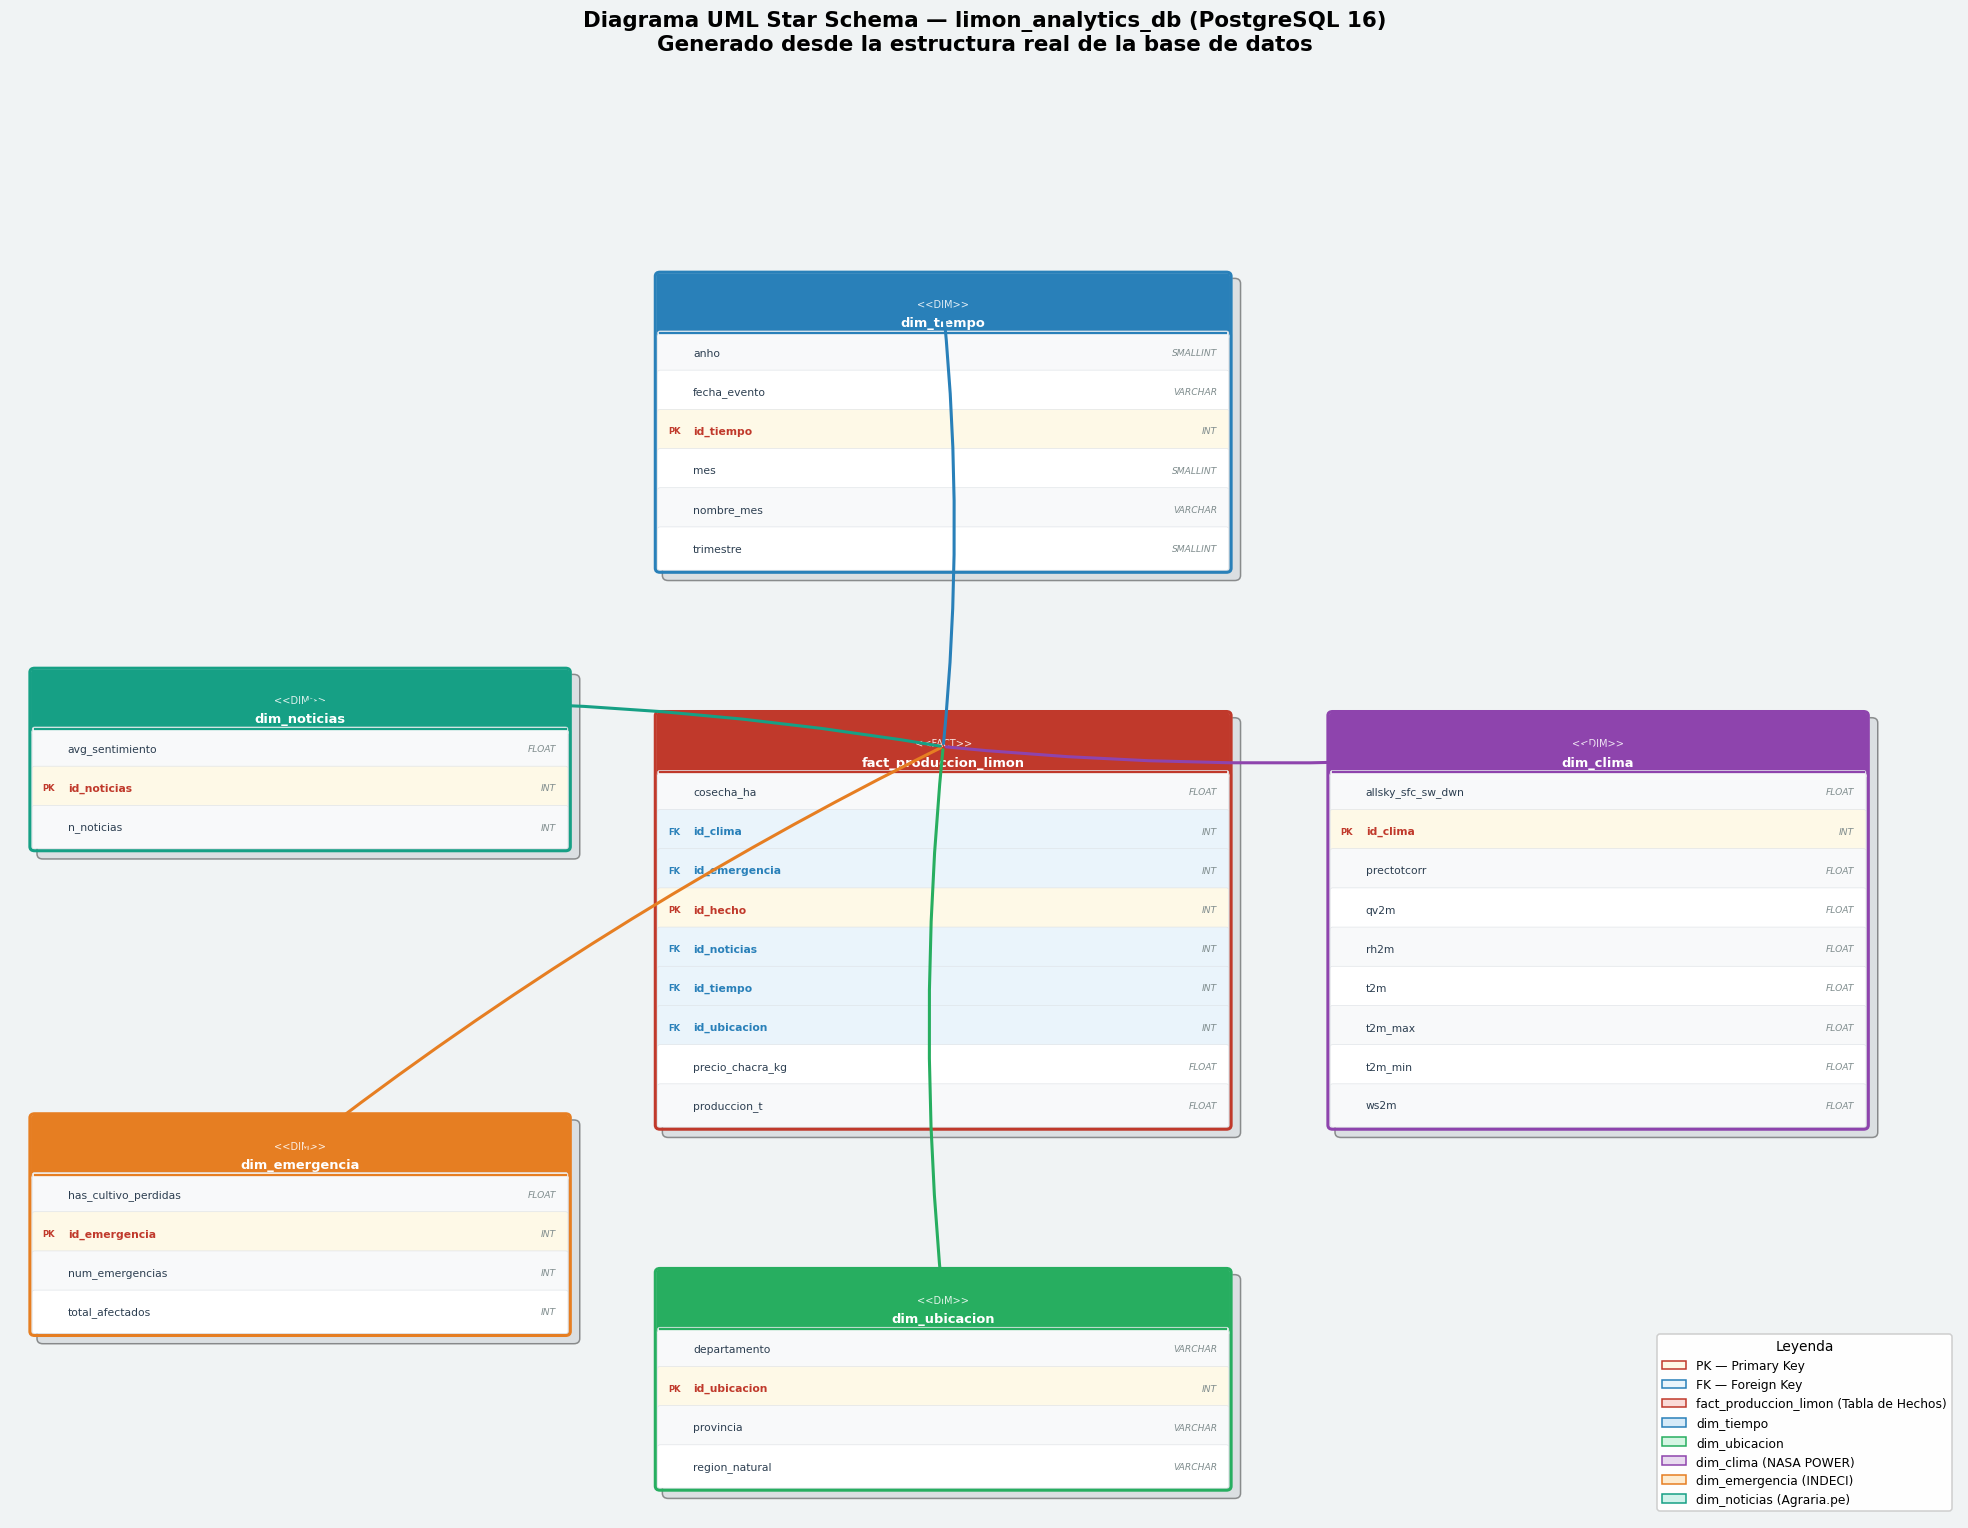

Guardado: pipeline/output/07_dwh/uml_star_schema_postgresql.png

Tablas incluidas en el diagrama:
  dim_tiempo                          6 columnas
  dim_ubicacion                       4 columnas
  dim_clima                           9 columnas
  dim_emergencia                      4 columnas
  dim_noticias                        3 columnas
  fact_produccion_limon               9 columnas


In [9]:
if PG_DISPONIBLE:
    import psycopg2
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch

    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    # Obtener columnas reales de cada tabla desde PostgreSQL
    tablas_config = [
        ('dim_tiempo',            5.5, 9.2,  4.8, '#2980b9'),
        ('dim_ubicacion',         5.5, 0.3,  4.8, '#27ae60'),
        ('dim_clima',             11.2, 3.8, 4.5, '#8e44ad'),
        ('dim_emergencia',        0.2,  1.8, 4.5, '#e67e22'),
        ('dim_noticias',          0.2,  6.5, 4.5, '#16a085'),
        ('fact_produccion_limon', 5.5,  3.8, 4.8, '#c0392b'),
    ]

    estructura_pg = {}
    for tabla, *_ in tablas_config:
        cursor.execute("""
            SELECT DISTINCT ON (c.column_name)
                c.column_name,
                c.data_type,
                CASE WHEN tc.constraint_type = 'PRIMARY KEY' THEN 'PK'
                     WHEN tc.constraint_type = 'FOREIGN KEY' THEN 'FK'
                     ELSE '' END as key_type
            FROM information_schema.columns c
            LEFT JOIN information_schema.key_column_usage kcu
                ON c.table_name = kcu.table_name
                AND c.column_name = kcu.column_name
                AND c.table_schema = kcu.table_schema
            LEFT JOIN information_schema.table_constraints tc
                ON kcu.constraint_name = tc.constraint_name
                AND kcu.table_schema = tc.table_schema
            WHERE c.table_name = %s AND c.table_schema = 'public'
            ORDER BY c.column_name, key_type DESC;
        """, (tabla,))
        estructura_pg[tabla] = cursor.fetchall()

    cursor.close()
    conn.close()

    # Dibujar el diagrama UML estrella
    fig, ax = plt.subplots(figsize=(18, 14))
    ax.set_xlim(0, 16.5)
    ax.set_ylim(0, 14)
    ax.axis('off')
    ax.set_facecolor('#f0f3f4')
    fig.patch.set_facecolor('#f0f3f4')

    def draw_uml_table(ax, x, y, w, tabla, cols, color_header):
        row_h = 0.38
        n_rows = len(cols)
        h_total = 0.55 + n_rows * row_h

        # Sombra
        shadow = FancyBboxPatch((x+0.07, y-0.07), w, h_total,
                                 boxstyle='round,pad=0.05',
                                 facecolor='#bdc3c7', alpha=0.4, zorder=1)
        ax.add_patch(shadow)

        # Header
        header = FancyBboxPatch((x, y + h_total - 0.55), w, 0.55,
                                 boxstyle='round,pad=0.04',
                                 facecolor=color_header, edgecolor='white',
                                 linewidth=1.5, zorder=2)
        ax.add_patch(header)
        tipo = 'FACT' if 'fact' in tabla else 'DIM'
        ax.text(x + w/2, y + h_total - 0.27, f'<<{tipo}>>', ha='center', va='center',
                fontsize=6.5, color='white', alpha=0.85, zorder=3)
        ax.text(x + w/2, y + h_total - 0.45, tabla, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='white', zorder=3)

        # Separador
        ax.plot([x, x+w], [y + h_total - 0.55, y + h_total - 0.55],
                color=color_header, linewidth=1.5, zorder=3)

        # Filas de columnas
        for i, (col_name, data_type, key_type) in enumerate(cols):
            row_y = y + h_total - 0.55 - (i+1)*row_h
            bg = '#fef9e7' if key_type == 'PK' else '#eaf4fb' if key_type == 'FK' else ('#f8f9fa' if i%2==0 else 'white')
            row_rect = FancyBboxPatch((x, row_y), w, row_h,
                                      boxstyle='round,pad=0.02',
                                      facecolor=bg, edgecolor='#dee2e6',
                                      linewidth=0.4, zorder=2)
            ax.add_patch(row_rect)

            # Icono key
            if key_type == 'PK':
                ax.text(x+0.12, row_y+row_h/2, 'PK', ha='center', va='center',
                        fontsize=5.5, color='#c0392b', fontweight='bold', zorder=3)
            elif key_type == 'FK':
                ax.text(x+0.12, row_y+row_h/2, 'FK', ha='center', va='center',
                        fontsize=5.5, color='#2980b9', fontweight='bold', zorder=3)

            # Nombre columna
            col_color = '#c0392b' if key_type=='PK' else '#2980b9' if key_type=='FK' else '#2c3e50'
            ax.text(x+0.28, row_y+row_h/2, col_name, ha='left', va='center',
                    fontsize=7, color=col_color,
                    fontweight='bold' if key_type in ('PK','FK') else 'normal', zorder=3)

            # Tipo dato
            tipo_short = (data_type
                .replace('character varying','VARCHAR')
                .replace('integer','INT')
                .replace('double precision','FLOAT')
                .replace('smallint','SMALLINT'))
            ax.text(x+w-0.08, row_y+row_h/2, tipo_short, ha='right', va='center',
                    fontsize=6, color='#7f8c8d', style='italic', zorder=3)

        # Borde exterior
        border = FancyBboxPatch((x, y), w, h_total,
                                 boxstyle='round,pad=0.04', fill=False,
                                 edgecolor=color_header, linewidth=2, zorder=4)
        ax.add_patch(border)
        return x + w/2, y + h_total  # centro superior

    # Dibujar todas las tablas
    centros = {}
    for tabla, x, y, w, color in tablas_config:
        cols = estructura_pg.get(tabla, [])
        cx, cy = draw_uml_table(ax, x, y, w, tabla, cols, color)
        centros[tabla] = (cx, cy)

    # Dibujar flechas FK (fact → dim)
    fact_cx = centros['fact_produccion_limon'][0]
    fact_cy_base = centros['fact_produccion_limon'][1] - 0.3

    fk_connections = [
        ('fact_produccion_limon', 'dim_tiempo',    '#2980b9'),
        ('fact_produccion_limon', 'dim_ubicacion', '#27ae60'),
        ('fact_produccion_limon', 'dim_clima',     '#8e44ad'),
        ('fact_produccion_limon', 'dim_emergencia','#e67e22'),
        ('fact_produccion_limon', 'dim_noticias',  '#16a085'),
    ]

    for origen, destino, color in fk_connections:
        ox = centros[origen][0]
        oy = centros[origen][1] - 0.3
        dx = centros[destino][0]
        dy = centros[destino][1] - 0.3
        ax.annotate('', xy=(dx, dy), xytext=(ox, oy),
                    arrowprops=dict(
                        arrowstyle='-|>',
                        color=color,
                        lw=2,
                        connectionstyle='arc3,rad=0.05'
                    ), zorder=5)

    # Titulo y leyenda
    ax.set_title(
        'Diagrama UML Star Schema — limon_analytics_db (PostgreSQL 16)\n'
        'Generado desde la estructura real de la base de datos',
        fontsize=14, fontweight='bold', pad=15
    )

    legend_elements = [
        mpatches.Patch(facecolor='#fef9e7', edgecolor='#c0392b', label='PK — Primary Key'),
        mpatches.Patch(facecolor='#eaf4fb', edgecolor='#2980b9', label='FK — Foreign Key'),
        mpatches.Patch(facecolor='#fadbd8', edgecolor='#c0392b', label='fact_produccion_limon (Tabla de Hechos)'),
        mpatches.Patch(facecolor='#d6eaf8', edgecolor='#2980b9', label='dim_tiempo'),
        mpatches.Patch(facecolor='#d5f5e3', edgecolor='#27ae60', label='dim_ubicacion'),
        mpatches.Patch(facecolor='#e8daef', edgecolor='#8e44ad', label='dim_clima (NASA POWER)'),
        mpatches.Patch(facecolor='#fdebd0', edgecolor='#e67e22', label='dim_emergencia (INDECI)'),
        mpatches.Patch(facecolor='#d1f2eb', edgecolor='#16a085', label='dim_noticias (Agraria.pe)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              framealpha=0.95, title='Leyenda', title_fontsize=9,
              bbox_to_anchor=(1.0, 0.0))

    plt.tight_layout()
    g_uml = OUTPUT['dwh'] + 'uml_star_schema_postgresql.png'
    plt.savefig(g_uml, dpi=130, bbox_inches='tight', facecolor='#f0f3f4')
    plt.show()
    print('Guardado:', g_uml)
    print()
    print('Tablas incluidas en el diagrama:')
    for tabla, *_ in tablas_config:
        n = len(estructura_pg.get(tabla, []))
        print(f'  {tabla:<35} {n} columnas')
else:
    print('PostgreSQL no disponible. Diagrama UML omitido.')


### Interpretacion

**Que muestra:** Las tablas e indices creados en PostgreSQL. Deben aparecer las 6 tablas del Star Schema y los 7 indices definidos en el DDL.

**Validacion:** Si alguna tabla falta, indica que hubo un error en la ejecucion del DDL. Se puede re-ejecutar la celda anterior para intentar de nuevo.

**Implicacion para el pipeline:** Con el esquema creado, la Actividad 9 puede insertar los datos del dataset integrado en PostgreSQL.


## Grafico 1 — Estado de las tablas creadas


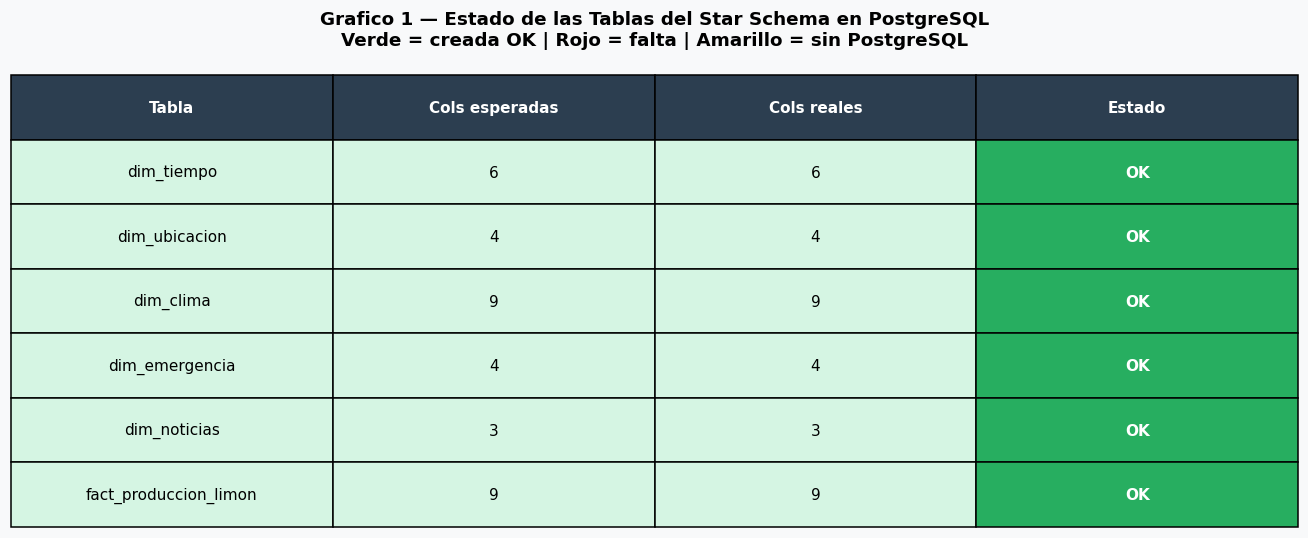

Guardado: pipeline/output/07_dwh/estado_tablas_pg.png


In [10]:
tablas_esperadas = [
    ('dim_tiempo',            6, '#2980b9'),
    ('dim_ubicacion',         4, '#27ae60'),
    ('dim_clima',             9, '#8e44ad'),
    ('dim_emergencia',        4, '#e67e22'),
    ('dim_noticias',          3, '#16a085'),
    ('fact_produccion_limon', 9, '#c0392b'),
]

if PG_DISPONIBLE:
    tablas_dict = {t[0]: t[1] for t in tablas}
    estados = [(nombre, cols_esp, color,
                'OK' if nombre in tablas_dict else 'FALTA',
                tablas_dict.get(nombre, 0))
               for nombre, cols_esp, color in tablas_esperadas]
else:
    estados = [(nombre, cols_esp, color, 'SIN PG', cols_esp)
               for nombre, cols_esp, color in tablas_esperadas]

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

headers = ['Tabla', 'Cols esperadas', 'Cols reales', 'Estado']
data_tabla = [[nombre, str(cols_esp), str(cols_real), estado]
              for nombre, cols_esp, color, estado, cols_real in estados]

tabla_vis = ax.table(
    cellText=data_tabla,
    colLabels=headers,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tabla_vis.auto_set_font_size(False)
tabla_vis.set_fontsize(10)

for (row, col), cell in tabla_vis.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        estado_fila = data_tabla[row-1][3] if row <= len(data_tabla) else ''
        if estado_fila == 'OK':
            cell.set_facecolor('#d5f5e3' if col < 3 else '#27ae60')
            if col == 3: cell.set_text_props(color='white', fontweight='bold')
        elif estado_fila == 'FALTA':
            cell.set_facecolor('#fadbd8' if col < 3 else '#e74c3c')
            if col == 3: cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#ffeeba' if col < 3 else '#f39c12')
            if col == 3: cell.set_text_props(color='white', fontweight='bold')

ax.set_title('Grafico 1 — Estado de las Tablas del Star Schema en PostgreSQL\n'
             'Verde = creada OK | Rojo = falta | Amarillo = sin PostgreSQL',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
g1 = OUTPUT['dwh'] + 'estado_tablas_pg.png'
plt.savefig(g1, dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Guardado:', g1)


### Interpretacion

**Que muestra:** El estado de cada tabla del Star Schema en PostgreSQL. Verde = creada correctamente, Rojo = falta, Amarillo = PostgreSQL no disponible.

**Validacion:** Todas las tablas deben aparecer en verde para confirmar que el esquema esta listo para recibir datos en la Actividad 9.

**Implicacion para el pipeline:** Si alguna tabla esta en rojo, re-ejecutar la celda de DDL. Si PostgreSQL no esta disponible, el pipeline puede continuar usando solo el CSV.


---
# 5. Prueba de Insercion (con Rollback)

Insertar registros de prueba para verificar que las FK funcionan correctamente. Se hace ROLLBACK al final para no dejar datos de prueba.


In [11]:
if PG_DISPONIBLE:
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    try:
        # dim_tiempo
        cursor.execute("""
            INSERT INTO dim_tiempo (fecha_evento, anho, mes)
            VALUES ('2099-01', 2099, 1) RETURNING id_tiempo;
        """)
        id_tiempo = cursor.fetchone()[0]
        print(f'  dim_tiempo: id_tiempo = {id_tiempo}')

        # dim_ubicacion
        cursor.execute("""
            INSERT INTO dim_ubicacion (departamento, provincia)
            VALUES ('TEST_DPTO', 'TEST_PROV') RETURNING id_ubicacion;
        """)
        id_ubicacion = cursor.fetchone()[0]
        print(f'  dim_ubicacion: id_ubicacion = {id_ubicacion}')

        # dim_clima (columnas del nuevo DDL: T2M, T2M_MAX, etc.)
        cursor.execute("""
            INSERT INTO dim_clima
            (t2m, t2m_max, t2m_min, prectotcorr,
             rh2m, qv2m, allsky_sfc_sw_dwn, ws2m)
            VALUES (26.1, 32.5, 20.3, 8.4, 61.9, 13.1, 21.7, 1.8)
            RETURNING id_clima;
        """)
        id_clima = cursor.fetchone()[0]
        print(f'  dim_clima: id_clima = {id_clima}')

        # dim_emergencia
        cursor.execute("""
            INSERT INTO dim_emergencia (num_emergencias, total_afectados, has_cultivo_perdidas)
            VALUES (2, 150, 5.3) RETURNING id_emergencia;
        """)
        id_emergencia = cursor.fetchone()[0]
        print(f'  dim_emergencia: id_emergencia = {id_emergencia}')

        # dim_noticias
        cursor.execute("""
            INSERT INTO dim_noticias (n_noticias, avg_sentimiento)
            VALUES (8, NULL) RETURNING id_noticias;
        """)
        id_noticias = cursor.fetchone()[0]
        print(f'  dim_noticias: id_noticias = {id_noticias}')

        # fact_produccion_limon
        cursor.execute("""
            INSERT INTO fact_produccion_limon
            (id_tiempo, id_ubicacion, id_clima, id_emergencia, id_noticias,
             produccion_t, cosecha_ha, precio_chacra_kg)
            VALUES (%s, %s, %s, %s, %s, 1250.5, 85.3, 1.85)
            RETURNING id_hecho;
        """, (id_tiempo, id_ubicacion, id_clima, id_emergencia, id_noticias))
        id_hecho = cursor.fetchone()[0]
        print(f'  fact_produccion_limon: id_hecho = {id_hecho}')

        print()
        print('OK: Todas las inserciones de prueba exitosas.')
        print('Las FK funcionan correctamente.')

        conn.rollback()
        print('ROLLBACK aplicado: datos de prueba eliminados.')
        print('La base de datos queda limpia para la Actividad 9.')

    except Exception as e:
        conn.rollback()
        print(f'ERROR: {e}')

    cursor.close()
    conn.close()
else:
    print('PostgreSQL no disponible.')


  dim_tiempo: id_tiempo = 1
  dim_ubicacion: id_ubicacion = 1
  dim_clima: id_clima = 1
  dim_emergencia: id_emergencia = 1
  dim_noticias: id_noticias = 1
  fact_produccion_limon: id_hecho = 1

OK: Todas las inserciones de prueba exitosas.
Las FK funcionan correctamente.
ROLLBACK aplicado: datos de prueba eliminados.
La base de datos queda limpia para la Actividad 9.


### Interpretacion

**Que muestra:** La prueba de insercion confirma que las claves foraneas funcionan correctamente y que el esquema acepta datos con la estructura esperada.

**Por que ROLLBACK:** Los datos de prueba no deben quedar en la base de datos. La Actividad 9 insertara los datos reales del dataset integrado.

**Implicacion para el pipeline:** Si la prueba de insercion falla, indica un problema en el DDL (tipos de datos incorrectos, FK mal definidas, etc.) que debe corregirse antes de la Actividad 9.


## Grafico 2 — Diagrama de conexion Python → PostgreSQL


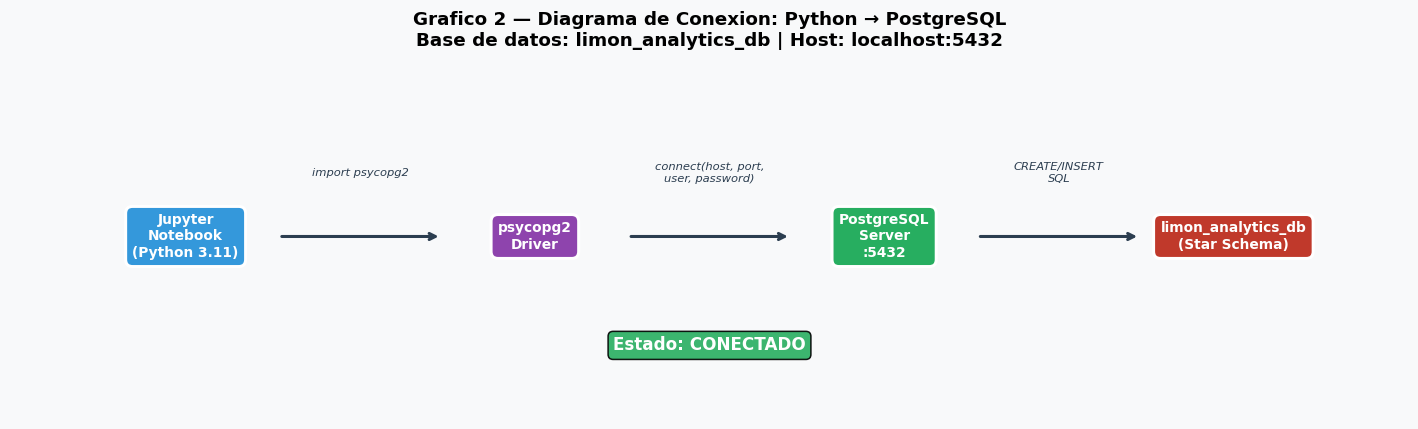

Guardado: pipeline/output/07_dwh/diagrama_conexion.png


In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

componentes = [
    ('Jupyter\nNotebook\n(Python 3.11)', '#3498db', 'white'),
    ('psycopg2\nDriver', '#8e44ad', 'white'),
    ('PostgreSQL\nServer\n:5432', '#27ae60', 'white'),
    ('limon_analytics_db\n(Star Schema)', '#c0392b', 'white'),
]
x_pos = [1.5, 4.5, 7.5, 10.5]

for (texto, fcolor, tcolor), x in zip(componentes, x_pos):
    ax.text(x, 2, texto, ha='center', va='center', fontsize=9,
            fontweight='bold', color=tcolor,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=fcolor,
                      edgecolor='white', linewidth=2))

# Flechas
for i in range(len(x_pos)-1):
    ax.annotate('', xy=(x_pos[i+1]-0.8, 2), xytext=(x_pos[i]+0.8, 2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

# Etiquetas sobre flechas
etiquetas = ['import psycopg2', 'connect(host, port,\nuser, password)', 'CREATE/INSERT\nSQL']
x_etiq = [3.0, 6.0, 9.0]
for etiq, x in zip(etiquetas, x_etiq):
    ax.text(x, 2.7, etiq, ha='center', va='center', fontsize=7.5,
            color='#2c3e50', style='italic')

# Estado de conexion
estado_txt = 'CONECTADO' if PG_DISPONIBLE else 'NO DISPONIBLE'
estado_color = '#27ae60' if PG_DISPONIBLE else '#e74c3c'
ax.text(6, 0.8, f'Estado: {estado_txt}', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white',
        bbox=dict(boxstyle='round', facecolor=estado_color, alpha=0.9))

ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.set_title('Grafico 2 — Diagrama de Conexion: Python → PostgreSQL\n'
             f'Base de datos: {PG_DB} | Host: {PG_HOST}:{PG_PORT}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g2 = OUTPUT['dwh'] + 'diagrama_conexion.png'
plt.savefig(g2, dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Guardado:', g2)


### Interpretacion

**Que muestra:** El flujo de conexion desde Python hasta PostgreSQL. El estado en la parte inferior indica si la conexion fue exitosa.

**Componentes:**
- `psycopg2`: el driver Python para PostgreSQL, ya instalado en el venv.
- `PostgreSQL Server`: el servidor de base de datos corriendo en localhost:5432.
- `limon_analytics_db`: la base de datos del proyecto con el Star Schema.

**Implicacion para el pipeline:** Esta conexion se reutilizara en la Actividad 9 para insertar los datos del dataset integrado en el Star Schema.


---
# 6. Resumen de la Actividad 8


In [13]:
print('=' * 70)
print('  ACTIVIDAD 8 COMPLETADA — ESQUEMAS EN POSTGRESQL')
print('=' * 70)
print()
print(f'PostgreSQL disponible: {PG_DISPONIBLE}')
if PG_DISPONIBLE:
    print(f'Base de datos: {PG_DB}')
    print(f'Tablas creadas: {len(tablas)}')
    print(f'Indices creados: {len(indices)}')
    print(f'Prueba de insercion: OK (con rollback)')
else:
    print('PostgreSQL no disponible.')
    print('El DDL esta guardado para ejecucion manual:')
    print(f'  {OUTPUT["dwh"]}dwh_star_schema.sql')
print()
print('Archivos generados:')
import glob
for f in sorted(glob.glob(OUTPUT['dwh'] + '*.png')):
    kb = os.path.getsize(f)//1024
    print(f'  {os.path.basename(f):<35} {kb} KB')
print()
print('Proximos pasos:')
print('  Actividad 9 -> Pipeline ETL completo (cargar datos en PostgreSQL)')


  ACTIVIDAD 8 COMPLETADA — ESQUEMAS EN POSTGRESQL

PostgreSQL disponible: True
Base de datos: limon_analytics_db
Tablas creadas: 6
Indices creados: 16
Prueba de insercion: OK (con rollback)

Archivos generados:
  cardinalidad_tablas.png             34 KB
  diagrama_conexion.png               53 KB
  estado_tablas_pg.png                47 KB
  flujo_etl.png                       62 KB
  mapeo_csv_dwh.png                   83 KB
  previsualizacion_schema.png         143 KB
  star_schema_uml.png                 149 KB
  uml_star_schema_postgresql.png      186 KB

Proximos pasos:
  Actividad 9 -> Pipeline ETL completo (cargar datos en PostgreSQL)
